In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Leer el archivo CSV
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv'
df = pd.read_csv(url)

# 2. Imprimir las primeras 5 filas y mostrar tipos de datos
print("--- Primeras 5 filas ---")
print(df.head())
print("\n--- Tipos de datos de cada columna ---")
print(df.dtypes)

# 3. Identificar y reemplazar valores nulos en 'horsepower'
# Primero checamos cuántos hay
nulos_antes = df['horsepower'].isnull().sum()
print(f"\nValores nulos encontrados en horsepower: {nulos_antes}")

# Calculamos la mediana con NumPy y reemplazamos
mediana_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana_hp)

# Verificamos que ya no haya nulos
print(f"Valores nulos después de la limpieza: {df['horsepower'].isnull().sum()}")

# 4. Crear la columna relacion_peso_potencia
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']

print("\n--- Columna 'relacion_peso_potencia' creada con éxito ---")
print(df[['name', 'weight', 'horsepower', 'relacion_peso_potencia']].head())

--- Primeras 5 filas ---
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

--- Tipos de datos de cada columna ---
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             objec

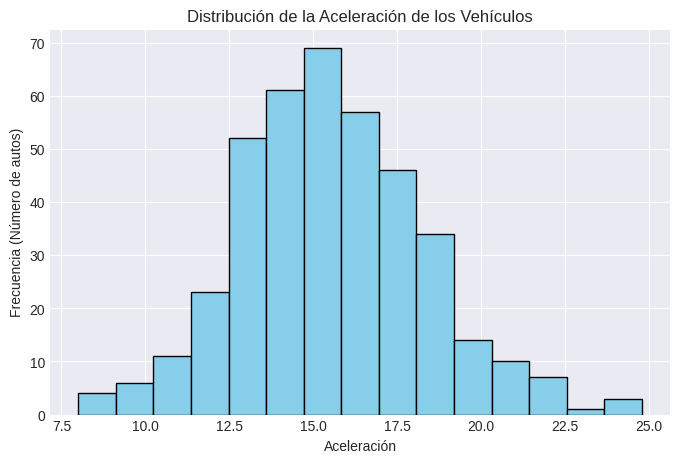

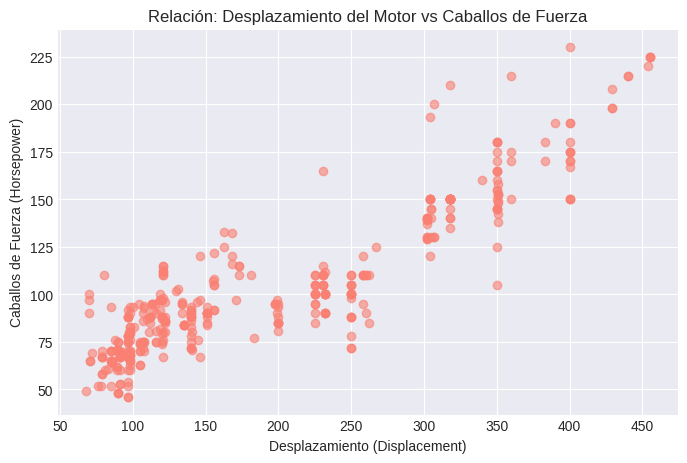

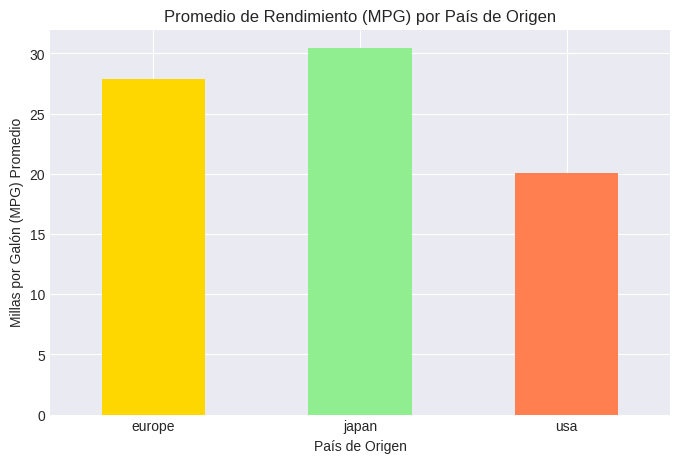

In [6]:
# Seteamos un estilo para que se vean chidotas
plt.style.use('seaborn-v0_8-darkgrid')

# --- 1. Histograma: Distribución de la aceleración ---
plt.figure(figsize=(8, 5))
plt.hist(df['acceleration'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribución de la Aceleración de los Vehículos')
plt.xlabel('Aceleración')
plt.ylabel('Frecuencia (Número de autos)')
plt.show()

# --- 2. Gráfico de Dispersión: Desplazamiento vs Caballos de fuerza ---
plt.figure(figsize=(8, 5))
plt.scatter(df['displacement'], df['horsepower'], color='salmon', alpha=0.6)
plt.title('Relación: Desplazamiento del Motor vs Caballos de Fuerza')
plt.xlabel('Desplazamiento (Displacement)')
plt.ylabel('Caballos de Fuerza (Horsepower)')
plt.show()

# --- 3. Gráfico de Barras: Promedio de MPG por Origen ---
# Primero agrupamos los datos
promedio_mpg_origen = df.groupby('origin')['mpg'].mean()

plt.figure(figsize=(8, 5))
promedio_mpg_origen.plot(kind='bar', color=['gold', 'lightgreen', 'coral'])
plt.title('Promedio de Rendimiento (MPG) por País de Origen')
plt.xlabel('País de Origen')
plt.ylabel('Millas por Galón (MPG) Promedio')
plt.xticks(rotation=0) # Para que los nombres no salgan de lado
plt.show()